In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jerusonj/transformer-weights/Transformer_weights (2).pth
/kaggle/input/datasets/jerusonj/lstm-weights/LSTM_weights (2).pth
/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv


In [12]:
import torch
import numpy as np

print(f"PyTorch Version: {torch.__version__}")

# 1. The Divine Fire: Checking if the GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

print("\n--- NumPy vs PyTorch Practice ---")

# 2. Creating a 2D array in NumPy (something you know)
np_array = np.array([[1.0, 2.0], [3.0, 4.0]])
print(f"NumPy Array:\n{np_array} (Type: {type(np_array)})")

# 3. Forging a PyTorch Tensor from that NumPy array
py_tensor = torch.from_numpy(np_array)
print(f"PyTorch Tensor:\n{py_tensor} (Type: {type(py_tensor)})")

# 4. Sending your tensor to the GPU warrior
if torch.cuda.is_available():
    gpu_tensor = py_tensor.to(device)
    print(f"\nTensor successfully sent to GPU! Device property: {gpu_tensor.device}")

PyTorch Version: 2.10.0+cpu
Using device: cpu

--- NumPy vs PyTorch Practice ---
NumPy Array:
[[1. 2.]
 [3. 4.]] (Type: <class 'numpy.ndarray'>)
PyTorch Tensor:
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64) (Type: <class 'torch.Tensor'>)


In [13]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

dataset_path = '/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv'
df = pd.read_csv(dataset_path)

df = df.drop(columns=['Date Time'], errors='ignore')
# np.arange(len(df)) // 6 creates groups like: 0,0,0,0,0,0, 1,1,1,1,1,1, 2,2...
#down sampled and didn't sample
df_hour_mean = df.groupby(np.arange(len(df)) // 6).mean()

# we drop'Date Time' string column
features = df_hour_mean[['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']].values

#80 percent for training and 20 percent for testing
split_idx_raw = int(len(features) * 0.8)
train_features = features[:split_idx_raw]
test_features = features[split_idx_raw:]

# Fit scaler only on training data, then transform both
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_features)
test_scaled = scaler.transform(test_features)

#recombining vertically so the sliding window loop works perfectly
features_scaled = np.vstack((train_scaled, test_scaled))

In [14]:
X = []
y = []

seq_length = 72
forecast_offset = 12
temp_index = 1 # 'T (degC)' is at index 1 in our features list

print("sliding windows")

for i in range(len(features_scaled) - seq_length - forecast_offset):
    # The 72 hour input sequence of 14 features
    window = features_scaled[i : i + seq_length]
    
    target = features[i + seq_length + forecast_offset - 1, temp_index]
   
    
    X.append(window)
    y.append(target)

#lists to tensors
X_tensor = torch.tensor(np.array(X), dtype=torch.float32)
y_tensor = torch.tensor(np.array(y), dtype=torch.float32)

print(f"Total Number Sequences : {len(X_tensor)}")
print(f"Shape of X_tensor: {X_tensor.shape} -> [Batches, Sequence Length, Features]")

sliding windows
Total Number Sequences : 70008
Shape of X_tensor: torch.Size([70008, 72, 14]) -> [Batches, Sequence Length, Features]


In [15]:
class JenaDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
        
    def __len__(self):
        return len(self.sequences)
        
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

#we split the data chronologically and seperate test and train set (80% goes for training and 20% goes for testing in chronological order)

split_idx = int(len(X_tensor) * 0.8)

train_dataset = JenaDataset(X_tensor[:split_idx], y_tensor[:split_idx])
test_dataset = JenaDataset(X_tensor[split_idx:], y_tensor[split_idx:])

#dataloaders
#batch size 256 is ok for 1D tensors
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

#verification
sequences, labels = next(iter(train_loader))
print(f"First Batch X shape: {sequences.shape}")
print(f"First Batch Y shape: {labels.shape}")
print(sequences[0][0])#will have 14 elements in the tensor 

First Batch X shape: torch.Size([256, 72, 14])
First Batch Y shape: torch.Size([256])
tensor([-1.5807, -0.5131, -0.3848, -0.5513, -0.0196, -0.6220, -0.6819, -0.3903,
        -0.6606, -0.6607,  0.0647,  2.1032,  1.8230,  0.2632])


In [16]:
class LSTM(nn.Module):
    def __init__(self, input_size=14, hidden_size=64, output=1):
        super().__init__()
        self.input_size = input_size
        
        # hidden dimension should be between 32 and 256
        self.hidden_size = hidden_size 
        
        # We concatenate the current input (x_t) and previous hidden state (h_{t-1})
        # So the weight matrices must accept the combined size
        combined_size = input_size + hidden_size
        
        # Forget Gate: decides what past memory to erase
        self.W_f = nn.Linear(combined_size, hidden_size)
        
        # Input Gate: decides what new information to let in
        self.W_i = nn.Linear(combined_size, hidden_size)
        
        # Candidate Cell State: the new potential information to add
        self.W_c = nn.Linear(combined_size, hidden_size)
        
        #  Output Gate: Decides what part of the memory becomes the new hidden state
        self.W_o = nn.Linear(combined_size, hidden_size)
        
        # Final Classifier
        self.fc = nn.Linear(hidden_size, output)

    def forward(self, x):
        # x shape gives [Batch_Size, Sequence_Length, Features],example [256, 72, 14]
        batch_size, seq_len, _ = x.size()
        device = x.device
        
        # initializing both hidden and cell state to all zeroes
        h_t = torch.zeros(batch_size, self.hidden_size).to(device)
        c_t = torch.zeros(batch_size, self.hidden_size).to(device)
        
        # Sliding through the 72 hours step by step
        for t in range(seq_len):
            #extracting the weather features for the current hour t
            x_t = x[:, t, :] 
            
            #concatenate current input and previous hidden state horizontally
            combined = torch.cat((x_t, h_t), dim=1)
            
            # applying the 5 LSTM equations mentioned above 
            
            #Forget Gate (sigmoid function brings the value between 0 and 1, 0 = forgetten completely)
            f_t = torch.sigmoid(self.W_f(combined))
            
            #Input Gate
            i_t = torch.sigmoid(self.W_i(combined))
            
            #Candidate cell state (Tanh function brings the value between -1 and 1)
            c_tilde = torch.tanh(self.W_c(combined))
            
            #Update cell state(Long Term Memory)
            c_t = (f_t * c_t) + (i_t * c_tilde)
            
            #output gate and the final hidden state updation
            o_t = torch.sigmoid(self.W_o(combined))
            h_t = o_t * torch.tanh(c_t)
            
        # after looping through all 72 hours, we take the hidden state
        # and pass it to our fully connected layer to make the prediction
        out = self.fc(h_t)
        return out

model_LSTM=LSTM().to(device)
print(model_LSTM)

LSTM(
  (W_f): Linear(in_features=78, out_features=64, bias=True)
  (W_i): Linear(in_features=78, out_features=64, bias=True)
  (W_c): Linear(in_features=78, out_features=64, bias=True)
  (W_o): Linear(in_features=78, out_features=64, bias=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [17]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, dim, max_len=5000):
        super().__init__()
        # dim is the hidden dimension of model (like 64)
        # max_len is the maximum sequence length we expect (72 hours, but 5000 is standard)

        # Create a long matrix of zeros with  shape [max_len, dim]
        pe = torch.zeros(max_len, dim)
        
        # Create a column vector of positions  [0, 1, 2, ... max_len-1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)#unsqueeze changes the row to coloum so [max_len,1]
        
        # the denominator is calculated (the 10000^(2i/dim) part)
        # we use exponentiation and natural log for numerical stability in PyTorch
        div_term = torch.exp(torch.arange(0, dim, 2).float() * (-math.log(10000.0) / dim))
        
        # applying sin to all even indices
        pe[:, 0::2] = torch.sin(position * div_term)
        
        # applying cos to all odd indices
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # on adding batch dimension the shape becomes [1, max_len, dim]
        pe = pe.unsqueeze(0)
        
        # registering as a buffer so PyTorch saves it with the model, but do not train it
        # positional encoding is a fixed mathematical wave, not weight
        self.register_buffer('pe', pe)

    def forward(self, x):
        #x shape  [Batch_Size, Sequence_Length, dim]
        #We simply ADD our positional waves to the input data
        
        # slicing the positional encoding to match the sequence length of x (for our cilmate data it will be 72)
        x = x + self.pe[:, :x.size(1), :]
        return x

#Testing
dim = 64
seq_length = 72
batch_size = 256

#test data
test_data = torch.zeros(batch_size, seq_length, dim)
positional_encoder = PositionalEncoding(dim=dim)

# Add the timestamps
pos_encoded_data = positional_encoder(test_data)

print(f"Original shape: {test_data.shape}")
print(f"post_Encoded_shape: {pos_encoded_data.shape}")
print("Positional Encoding is successfully")

Original shape: torch.Size([256, 72, 64])
post_Encoded_shape: torch.Size([256, 72, 64])
Positional Encoding is successfully


In [18]:
class Transformer_Prime(nn.Module):
    def __init__(self, features=14, dim=64, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        
        # Feature Projection Layer
        # the Transformer needs an embedding dimension of 64, but we only have 14 weather features.
        # this linear layer stretches our 14 features into the required 64 dimensions.
        self.feature_projection = nn.Linear(features, dim)
        
        # positional encoding
        self.pos_encoder = PositionalEncoding(dim=dim)
        
        # Transformer Encoder
        # batch_first=True is needed as our data comes in as [Batch, Sequence, Features]
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, 
            nhead=num_heads, 
            dim_feedforward=dim * 4, 
            dropout=dropout, 
            batch_first=True
        )
        # we stack two layers together
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # regression layer
        # takes the output and squashes it into a single temperature prediction
        self.regressor = nn.Linear(dim, 1)

    def forward(self, x):
        # x shape [Batch, 72, 14]
        
        # Step 1: Project features -> Shape becomes [Batch, 72, 64]
        x = self.feature_projection(x)
        
        # Step 2: Add our timestamps
        x = self.pos_encoder(x)
        
        # Step 3: transformer calculates all the attention weights
        x = self.transformer_encoder(x)
        
        # Step 4: we Get the output of the laast hour in the sequence (index -1)
        # We use the final hour's context to predict the future temperature
        last_hour = x[:, -1, :]  # Shape becomes [Batch, 64]
        
        # Step 5: final regression prediction -> Shape becomes [Batch, 1]
        prediction = self.regressor(last_hour)
        
        return prediction

# Test
Test_data = torch.randn(256, 72, 14)

# Initialize the model
test_model = Transformer_Prime()

# data through model
Test_prediction = test_model(Test_data)

print(f"Input shape: {Test_data.shape}")
print(f"Output prediction shape: {Test_prediction.shape}")
print("Transformer Architecture is successfully connected!")

model_TRANSFORMER=Transformer_Prime().to(device)
print(model_TRANSFORMER)

Input shape: torch.Size([256, 72, 14])
Output prediction shape: torch.Size([256, 1])
Transformer Architecture is successfully connected!
Transformer_Prime(
  (feature_projection): Linear(in_features=14, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (regressor): Linea

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# map_location=device ensures it loads correctly whether we have GPU turned on or off
model_LSTM.load_state_dict(torch.load("/kaggle/input/datasets/jerusonj/lstm-weights/LSTM_weights (2).pth", map_location=device))
model_TRANSFORMER.load_state_dict(torch.load("/kaggle/input/datasets/jerusonj/transformer-weights/Transformer_weights (2).pth", map_location=device))

# Set to evaluation mode for plot
model_LSTM.eval()
model_TRANSFORMER.eval()

print("Both models Loaded")

Both models Loaded


--- Generating Final Comparison Plot ---


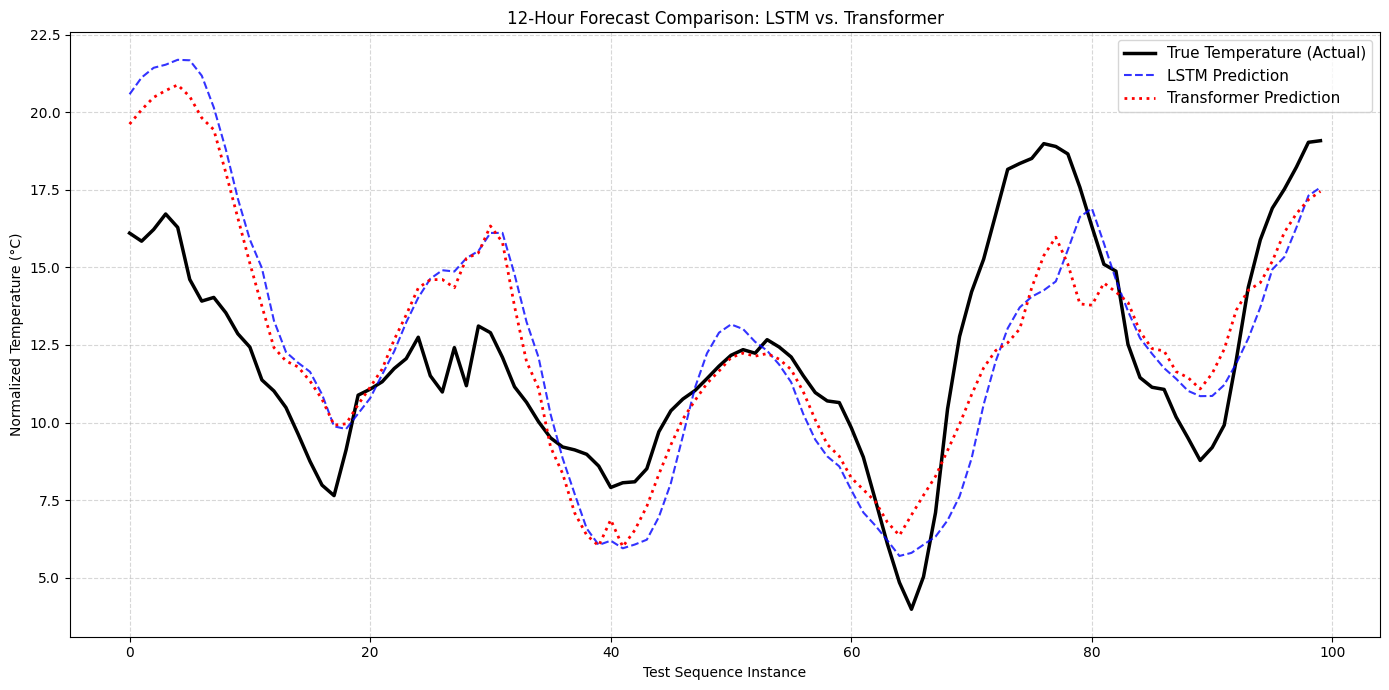

In [20]:
import torch
import matplotlib.pyplot as plt

print("--- Generating Final Comparison Plot ---")
# Grab a single batch of unseen test data
inputs, labels = next(iter(test_loader))
inputs, labels = inputs.to(device), labels.to(device)

# Generate predictions from both architectures
with torch.no_grad():
    lstm_predictions = model_LSTM(inputs).squeeze()
    transformer_predictions = model_TRANSFORMER(inputs).squeeze()

# 4. Move data back to CPU and convert to NumPy for Matplotlib
plot_range = 100 

actual_temps = labels.cpu().numpy()[:plot_range]
lstm_preds = lstm_predictions.cpu().numpy()[:plot_range]
transformer_preds = transformer_predictions.cpu().numpy()[:plot_range]

# comparison plot
plt.figure(figsize=(14, 7))

# True Temperature (Black)
plt.plot(actual_temps, label='True Temperature (Actual)', color='black', linewidth=2.5)

# LSTM (Blue Dashed)
plt.plot(lstm_preds, label='LSTM Prediction', color='blue', linestyle='--', alpha=0.8)

# Transformer (Red Dotted)
plt.plot(transformer_preds, label='Transformer Prediction', color='red', linestyle=':', linewidth=2)

plt.title('12-Hour Forecast Comparison: LSTM vs. Transformer')
plt.xlabel('Test Sequence Instance')
plt.ylabel('Normalized Temperature (°C)')
plt.legend(loc='best', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Comparision of LSTM Vs Transformer Prediction

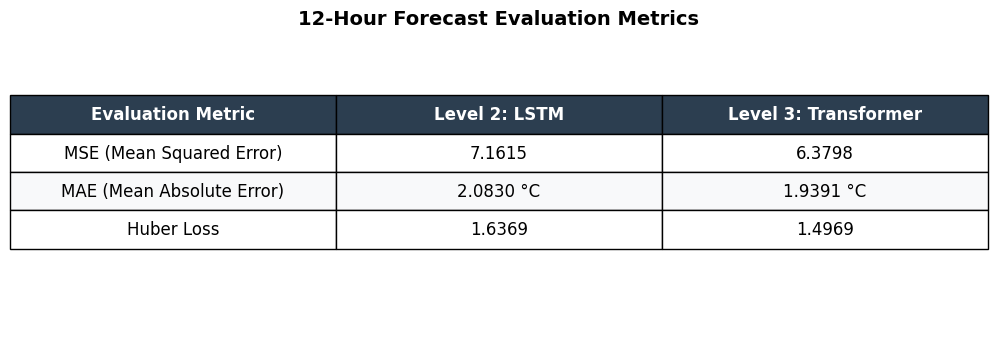

In [28]:
import matplotlib.pyplot as plt

# 1. Define your data here!
# Replace the placeholder text in these lists with the exact final numbers from your logs
metrics = ['MSE (Mean Squared Error)', 'MAE (Mean Absolute Error)', 'Huber Loss']
lstm_scores = ['7.1615', '2.0830 °C', '1.6369']
transformer_scores = ['6.3798', '1.9391 °C', '1.4969']

# 2. Combine the data into rows for the Matplotlib table
table_data = []
for i in range(len(metrics)):
    table_data.append([metrics[i], lstm_scores[i], transformer_scores[i]])

columns = ['Evaluation Metric', 'Level 2: LSTM', 'Level 3: Transformer']

# 3. Initialize the plot
fig, ax = plt.subplots(figsize=(10, 3.5))

# Hide the standard chart axes since we are just drawing a table
ax.axis('tight')
ax.axis('off')

# 4. Create the table
table = ax.table(cellText=table_data, 
                 colLabels=columns, 
                 loc='center', 
                 cellLoc='center')

# 5. Stylize the table for a professional look
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2) # Adjust column width and row height

# Add colors and bold text to the header row
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50') # Dark blue header
    else:
        # Alternating row colors (zebra striping) for readability
        cell.set_facecolor('#f8f9fa' if row % 2 == 0 else '#ffffff') 

# 6. Add a title and display
plt.title('12-Hour Forecast Evaluation Metrics', fontweight='bold', fontsize=14, y=0.95)
plt.tight_layout()
plt.show()

# LSTM VS TRANSFORMER Metrics